This notebook is an example using only one minibox of what the script does for all the miniboxes we divided the simulation into

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
# ASTRID cosmology values
hubble, z = 0.6774, 2.5

# Calculating Px

As I will need to obtain the radial separation between two skewers, I cannot mask just yet. I need to do that afterwards. We will call a folder that contains all the deltas without any masking

In [ ]:
data = '/pscratch/sd/l/lflores/astrid_hcd_outputs/FFTs/ffts_0.3_24/minibox_01.hdf5'
Nmbox = 25

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for k in f.attrs.keys():
        print(f'{k} = {f.attrs[k]}')
    print('----------------') 
    # Atributes
    logNHi_min = f.attrs['logNHI_min']
    logNHi_max = f.attrs['logNHI_max']
    smth_factor = f.attrs['Smoothing factor']
    Lbox = f.attrs['box_size_Mpch']
    Lmbox = f.attrs['minibox_size_Mpch']
    Nsk = f.attrs['skewers_per_side']
    Np = f.attrs['pixels_per_skewer']
    Pw = f.attrs['pixel_width_Mpch']
    Ssk = f.attrs['skewer_separation_Mpch']
    print('Data:')
    print(f.keys())
    # Data
    fft_tot = f['fft_tot'][:]
    print('fft_tot shape:', fft_tot.shape)
    fft_lya = f['fft_lya'][:]
    print('fft_lya shape:', fft_lya.shape)
    fft_hcd = f['fft_hcd'][:]
    print('fft_hcd shape:', fft_hcd.shape)
    fft_lyahcd = f['fft_lyahcd'][:]
    print('fft_lyahcd shape:', fft_lyahcd.shape)
    k_los = f['k_los'][:]
    print('k_los shape', k_los.shape)
    C = f['C'][()]
    print('C = ', C)
    colden = f['colden'][:]
    print('colden shape', colden.shape)


## Radial distance

In [32]:
ix, iy = np.divmod(np.arange(Nsk), Lmbox)  # This gives me the coordinates of each skewer within the minibox
dx = ix[:, None] - ix[None, :]
dy = iy[:, None] - iy[None, :]
dr = np.sqrt(dx**2 + dy**2)*Ssk  # This matrix contains the radial distance (Mpc/h) between all skewers within the minibox

In [33]:
r_bins = np.linspace(dr.min(), dr.max(), 6)  # 5 radial bins Mpc/h
print('Radial edges (Mpc/h) to the', len(r_bins), 'defined radial bins:', r_bins)

Radial edges (Mpc/h) to the 6 defined radial bins: [ 0.          4.9010203   9.8020406  14.70306091 19.60408121 24.50510151]


## Masking skewers

In [34]:
from Calculate_deltas import mask_skewers

logNHi_min, logNHi_max = 0, 21.3
_, _, (fft_tot_mask, fft_lya_mask, fft_hcd_mask, fft_lyahcd_mask, dr_flatten_mask) = mask_skewers(colden, logNHi_min, logNHi_max, Nsk, fft_tot, fft_lya, fft_hcd, fft_lyahcd, dr.flatten())

## Computing Px

### Total

In [50]:
px_tot = []
for i, r_value in enumerate(r_bins[:-1]):
    r_mask = (dr_flatten_mask > r_value) & (dr_flatten_mask < r_bins[i+1])
    fft_tot_2mask = fft_tot_mask[r_mask]
    
    pxs_tot = fft_tot_2mask*fft_tot_2mask.conjugate()*Lbox/(Np**2)
    px_tot.append(np.mean(pxs_tot, axis=0))
px_tot = np.array(px_tot)

/tmp/ipykernel_1166172/2402309805.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


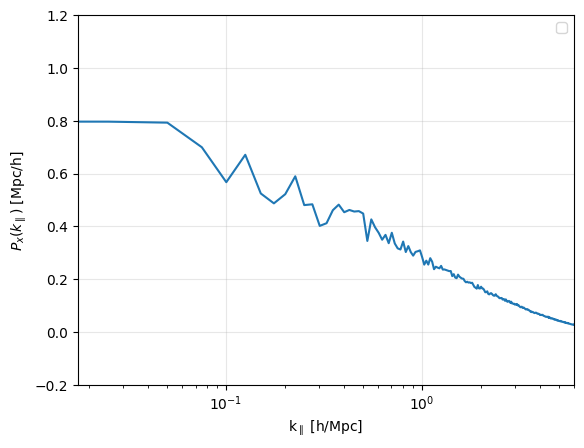

In [39]:

for i in np.arange(len(r_bins-1)):
    plt.plot(k_los, px_tot)
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.ylim(-0.2, 1.2)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]');